=== BASELINE SVM CLASSIFIER ===
Accuracy: 0.7816
F1 Score: 0.7982
Runtime: 2.05 seconds
--------------------------------------------------
--- Tuning Parameter Set 1 ---
Best Params: {'C': 0.5, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 0.7816, F1 Score: 0.7982, Runtime: 11.33s

--- Tuning Parameter Set 2 ---
Best Params: {'C': 2.0, 'gamma': 'auto', 'kernel': 'rbf'}
Accuracy: 0.7427, F1 Score: 0.7665, Runtime: 17.25s

--- Tuning Parameter Set 3 ---
Best Params: {'C': 0.5, 'gamma': 'auto', 'kernel': 'linear'}
Accuracy: 0.7816, F1 Score: 0.7982, Runtime: 15.97s



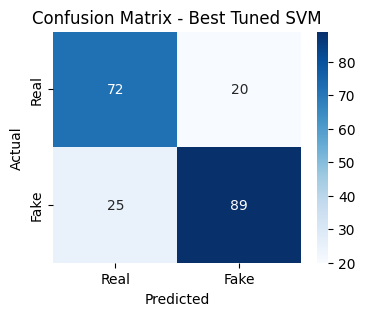


=== SVM MODEL COMPARISON ===
        Set                                       Best Params  Accuracy  \
0  Baseline                                           Default    0.7816   
1         1  {'C': 0.5, 'gamma': 'scale', 'kernel': 'linear'}    0.7816   
2         2      {'C': 2.0, 'gamma': 'auto', 'kernel': 'rbf'}    0.7427   
3         3   {'C': 0.5, 'gamma': 'auto', 'kernel': 'linear'}    0.7816   

   F1 Score  Runtime (s)  
0    0.7982         2.05  
1    0.7982        11.33  
2    0.7665        17.25  
3    0.7982        15.97  

=== CROSS-VALIDATION F1 SCORES (Best Tuned Model) ===
[0.82352941 0.78306878 0.80203046 0.83516484 0.75      ]
Mean CV F1 Score: 0.7988


In [8]:
#  MODEL 5: SVM CLASSIFIER
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("final_preprocessed_vectorized.csv")

# Features and target
tfidf_cols = [c for c in df.columns if c.startswith('tfidf_')]
X = df[tfidf_cols]
y = df['class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler(with_mean=False)
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Baseline SVM
svm_base = SVC(kernel='linear', random_state=42)
start = time.time()
svm_base.fit(X_train_s, y_train)
yp_base = svm_base.predict(X_test_s)
end = time.time()
baseline_runtime = round(end - start, 2)

print("=== BASELINE SVM CLASSIFIER ===")
print("Accuracy:", round(accuracy_score(y_test, yp_base),4))
print("F1 Score:", round(f1_score(y_test, yp_base),4))
print("Runtime:", baseline_runtime, "seconds")
print("-"*50)

# Parameter tuning
param_sets = [
    {'C':[0.5,1.0], 'kernel':['linear'], 'gamma':['scale']},
    {'C':[1.0,2.0], 'kernel':['rbf'], 'gamma':['scale','auto']},
    {'C':[0.5,1.5], 'kernel':['linear','rbf'], 'gamma':['auto']}
]

best_score = 0
best_model = None
best_params = None
tuning_results = []

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for i, params in enumerate(param_sets, 1):
    print(f"--- Tuning Parameter Set {i} ---")
    svm_model = SVC(random_state=42)

    start = time.time()
    grid = GridSearchCV(svm_model, params, cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train_s, y_train)
    end = time.time()
    runtime = round(end - start, 2)

    yp = grid.predict(X_test_s)
    acc = accuracy_score(y_test, yp)
    f1 = f1_score(y_test, yp)

    tuning_results.append({
        'Set': i,
        'Best Params': grid.best_params_,
        'Accuracy': round(acc,4),
        'F1 Score': round(f1,4),
        'Runtime (s)': runtime
    })

    print(f"Best Params: {grid.best_params_}")
    print(f"Accuracy: {round(acc,4)}, F1 Score: {round(f1,4)}, Runtime: {runtime}s\n")

    if f1 > best_score:
        best_score = f1
        best_model = grid.best_estimator_
        best_params = grid.best_params_

# Confusion Matrix for Best Tuned Model
yp_best = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, yp_best)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("Confusion Matrix - Best Tuned SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Comparison Table
comparison_df = pd.DataFrame(tuning_results)
baseline_row = pd.DataFrame([{
    'Set': 'Baseline',
    'Best Params': 'Default',
    'Accuracy': round(accuracy_score(y_test, yp_base),4),
    'F1 Score': round(f1_score(y_test, yp_base),4),
    'Runtime (s)': baseline_runtime
}])
comparison_df = pd.concat([baseline_row, comparison_df], ignore_index=True)
print("\n=== SVM MODEL COMPARISON ===")
print(comparison_df)

# Cross-validation on Best Tuned Model
cv_scores = cross_val_score(best_model, X_train_s, y_train, cv=5, scoring='f1')
print("\n=== CROSS-VALIDATION F1 SCORES (Best Tuned Model) ===")
print(cv_scores)
print("Mean CV F1 Score:", round(np.mean(cv_scores),4))
